## <strong>第四次作品：卷積神經網路 CNN 在影像辨識與超解析生成的練習</strong>
作業編號：4

學號：711133108

姓名：林楷博
<hr>

 <font color=skyblue>作品目標</font>：
- 數據預處理：
    - 數據分割：將原始資料集劃分為訓練集和測試集。
    - 標準化：對資料進行標準化處理，以提高模型訓練效果。
    - 格式轉換：將標準化後的資料轉換為 PyTorch 格式，並調整形狀以適應 CNN 輸入要求。
- 數據載入：
    - 創建資料載入器：使用 DataLoader 創建訓練集和測試集的載入器，便於批量處理資料，並打亂訓練資料順序以提高訓練效果。
- 定義 CNN 模型：
    - 模型架構：定義一個簡單的卷積神經網路，包括卷積層、全連接層和啟動函數，以用於圖像分類任務。
    - 模型初始化：將模型載入到 GPU（如果可用）或 CPU 上進行訓練。
    - 定義損失函數和優化器：
- 模型訓練：
   - 訓練過程：對模型進行多次（50個epoch）訓練，逐批次（batch）輸入資料，計算損失，反向傳播，更新模型參數。
   - 記錄準確率：在每個 epoch 結束後計算並記錄測試集的準確率，以便後續繪圖。
- 繪製準確率曲線：
   - 繪圖：繪製模型在 50 個 epoch 中的準確率變化曲線，以視覺化訓練過程中的性能變化。
- 評估模型在測試集上的表現：
   - 計算準確率：在整個測試集上計算模型的準確率，評估模型的整體性能。
- 隨機選取並評估10張測試圖像：
   - 隨機選取：從測試集中隨機選取 10 張圖像進行單獨評估。
   - 預測標籤：通過模型預測這 10 張圖像的標籤，並列印實際標籤和預測標籤。
   - 計算準確率：計算這 10 張圖像的準確率，展示模型在小規模資料上的性能。
- 模型儲存

### **<font color=skyblue>匯入資料與資料呈現</font>**
- Yale Face 資料集是一個著名的人臉識別數據集，該數據集由耶魯大學（Yale University）提供。資料集主要用於研究人臉識別和表情識別問題，並在機器學習和計算機視覺領域被廣泛使用。以下是該數據庫的介紹：
    - 圖像內容：Yale Face 資料集包含了許多不同的人臉圖像，這些圖像是以不同的表情、姿勢和光照條件拍攝的。這些圖像為研究人臉識別的挑戰提供了豐富的變異性。數據庫有 38 人的人臉影像，並且每個人的照片數 59~64 張，共計 2410 張
    - 圖像解析度：圖像的解析度相對較低，但在研究中仍然是有用的。 每張圖片都是灰階圖像，大小為192×168圖元。
    - 表情和姿勢：資料集中的人臉圖像包括不同的表情，如微笑、皺眉和閉眼等，還有不同的姿勢，如側面和正面等。
    - 光照條件：圖像是在不同的光照條件下拍攝的，這對於研究光照變化對人臉識別的影響非常重要。   

C:\Users\jameslin\AppData\Local\Temp\ipykernel_19372\3192010909.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(D['m']) # 168
C:\Users\jameslin\AppData\Local\Temp\ipykernel_19372\3192010909.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(D['n']) # 192
C:\Users\jameslin\AppData\Local\Temp\ipykernel_19372\3192010909.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n_persons = int(D['person']) # 38


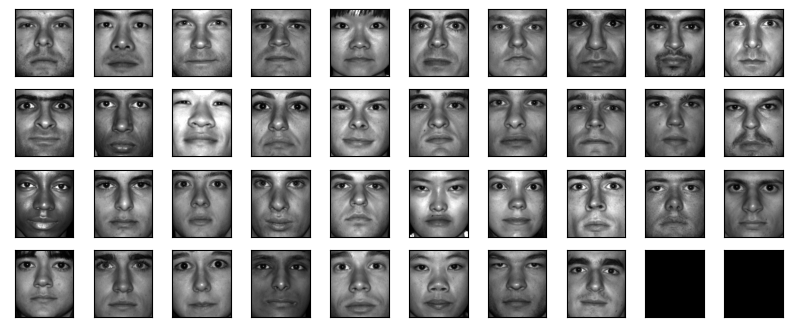

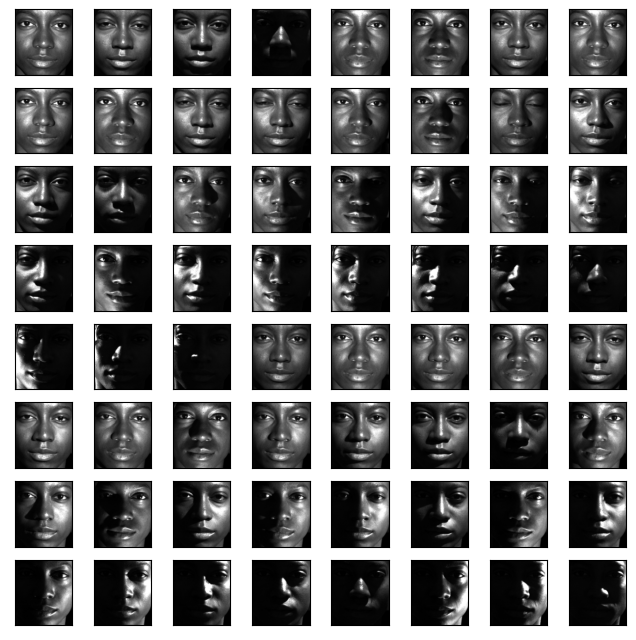

In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.io

def show_montage(X, n, m, h, w):
    # X: 影 像 資 料 矩 陣 ， 每 行 代 表 一 張 影 像
    # n, m: 每 張 影 像 的 大 小 n x m
    # h, w : 建 立 一 個 蒙 太 奇 圖 陣 ， 大小 figsize = (w,h)
    fig, axes = plt.subplots(h, w, figsize=(w, h))
    if X.shape[1] < w * h: # 影 像 張 數 不 到 w x h 張 ， 用 0 向量補齊
        X = np.c_[X, np.zeros((X.shape[0], w*h-X.shape[1]))]
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[:,i].reshape(m, n).T, cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

D = scipy.io.loadmat('allFaces.mat')
X = D['faces'] # 32256 x 2410, each column represents an image
m = int(D['m']) # 168
n = int(D['n']) # 192
n_persons = int(D['person']) # 38
y2 = np.ndarray.flatten(D['nfaces']) # 每個人的照片數59~64
y = np.repeat(np.arange(len(y2)),y2) # 每張照片的label

# 展示38人第一張影像檔
all_diff_persons = np.zeros((m*n, n_persons))
cnt = 0
for i in range(n_persons):
    all_diff_persons[:,i] = X[:,cnt]
    cnt = cnt + y2[i]
show_montage(all_diff_persons, n, m, 4,10)

# 展示某個人的所有樣本影像
which_person = 20 # 0 ~ 37
start_col = y2[0:which_person]. sum()
end_col = start_col + y2[which_person]
show_montage(X[:, start_col:end_col], n, m, 8, 8)

### **<font color=skyblue>結果的觀察與討論：</font>**
- 資料呈現
    - 38 人的人臉影像，並且每個人的照片數 59~64 張，共計 2410 張，每張照片像素為 192\*168 (32256) ，因此資料矩陣 X 為 32256\*2410 的大小。
    - 變數 y 為 2410*1 2的矩陣，為 2410 張照片的 target
    - 上一圖呈現38人每人第一張的人臉影像，共計 38 張。
    - 上二圖呈現特定人的全部影像，共計 59~64 張。

### **<font color=skyblue>資料處理</font>**
- 資料分割透過train_test_split套件分為8成訓練集與2成測試集，並使用種子碼random_state固定結果
- 資料透過StandardScaler套件標準化(可以不做)
- 資料ndarry格式透過torch套件轉換為Tensor格式，最終轉換為TensorDataset格式方便後續GPU運算
- 透過shuffle指令增加樣本隨機性，提高網路的泛化效能，避免因為有規律的資料出現，導致權重更新時的梯度過於極端，避免最終模型過度擬合或欠擬合
- 使用batch_size 處理每次迭代模型的樣本數

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# 原始資料分為8比2的訓練集跟測試集
X_train, X_test, y_train, y_test = train_test_split(
    X.T, y, test_size=0.20, random_state=12345)
# 標準化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
 
# 轉成torch格式
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).long()
X_train = X_train.reshape(-1, 1, 192, 168) # convert to N x 1 x 192 x 168 for CNN
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).long()
X_test = X_test.reshape(-1, 1, 192, 168) # N x 1 x 192 x 168
 
# check shapes of data
print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)
print("X_test.shape:", X_test.shape)
print("y_test.shape:", y_test.shape)
 
# create dataloaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

X_train.shape: torch.Size([1928, 1, 192, 168])
y_train.shape: torch.Size([1928])
X_test.shape: torch.Size([482, 1, 192, 168])
y_test.shape: torch.Size([482])


### **<font color=skyblue>結果的觀察與討論：</font>**
- 資料矩陣 X 為 32256\*2410 轉換成訓練集1928筆資料，與測試集482筆資料，共計2410筆資料，並且將每筆資料轉換為N x 1 x 192 x 168的格式，方便後續CNN模型使用，N分別為訓練集X_train與測試集X_test筆數

## <font color=orange>CNN 模型</font>：<br>
卷積神經網絡（Convolutional Neural Networks，CNNs）是深度學習中一種特別適合於圖像處理和計算機視覺任務的神經網絡結構。CNN 的設計靈感來自於生物學上視覺皮層的組織結構，其核心思想是使用卷積層來提取圖像中的局部特徵，並逐層構建高級特徵表示。以下是對 CNN 模型的詳細介紹：
- 卷積層 (Convolutional Layer)是 CNN 的基礎構建單元，它通過卷積運算提取輸入數據的局部特徵。卷積層的主要參數包括卷積核（或濾波器）的大小、數量、步幅（stride）和填充（padding）。

    - 卷積運算：卷積核在輸入數據上滑動，計算其與輸入數據局部區域的點積和，從而得到特徵圖（feature map）。
    - 特徵圖：每個卷積核提取輸入數據的一種特徵，特徵圖的深度等於卷積核的數量。
- 激活層 (Activation Layer)通常緊隨卷積層之後，用於引入非線性因素，使網絡能夠學習更複雜的特徵。常用的激活函數有 ReLU（Rectified Linear Unit）、Sigmoid 和 Tanh。
    - ReLU：將所有負值置零，保留正值，公式為ReLU(𝑥)=max(0,𝑥)
- 池化層 (Pooling Layer)用於減少特徵圖的尺寸，從而減少計算量和內存使用。池化層的主要類型有最大池化（Max Pooling）和平均池化（Average Pooling）。
    - 最大池化：取池化窗口內的最大值。
    - 平均池化：取池化窗口內的平均值。
- 全連接層 (Fully Connected Layer)將前一層提取的特徵展平成一維向量，並通過矩陣乘法與一組權重相乘，進行分類或回歸任務。全連接層的輸出通常用於最終的決策層。
- Dropout層 (Dropout Layer)在訓練過程中隨機將一些神經元設為零，以防止過擬合，並提高模型的泛化能力。

### **<font color=skyblue>CNN模型建立</font>**
- 定義CNN模型結構
- 設定設備（GPU 或 CPU）

In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F
 
class Net(nn.Module):
 
    def __init__(self):
        super(Net, self).__init__()
         
        self.conv1 = nn.Conv2d(1, 6, 5) # 1 input channel, 6 output channels, 5x5 square convolution
        self.conv2 = nn.Conv2d(6, 16, 5) # 6 input channel, 16 output channels, 5x5 square convolution
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 45 * 39, 120)  # 4*4 from image dimension 
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 38) # 38 output classes
 
    def forward(self, x):
         
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2)) # Max pooling over a (2, 2) window
        # If the size is a square, you can specify with a single number
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = torch.flatten(x, 1) # flatten all dimensions except the batch dimension
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
 
 
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))
 
net = Net().to(device)
print(net)

Using cuda:0 device
Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=28080, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=38, bias=True)
)


### **<font color=skyblue>結果的觀察與討論：</font>**
-  定義 CNN 模型
    - CNN 層結構：
        - self.conv1 = nn.Conv2d(1, 6, 5)
            - 意思為卷積層1 (conv1)：將輸入的 1 個通道轉換為 6 個通道，使用 5x5 的卷積核。
        - self.conv2 = nn.Conv2d(6, 16, 5)
            - 意思為卷積層2 (conv2)：將卷積層1的 6 個輸入通道轉換為 16 個通道，使用 5x5 的卷積核。
        - self.fc1 = nn.Linear(16 * 45 * 39, 120)
            - 全連接層1 (fc1)：輸入是展平後的 16 個 45x39 的特徵圖，輸出是 120 維的向量。
        - self.fc2 = nn.Linear(120, 84)
            - 全連接層2 (fc2)：輸入是 120 維的向量，輸出是 84 維的向量。
        - self.fc3 = nn.Linear(84, 38)
            - 全連接層3 (fc3)：輸入是 84 維的向量，輸出是 38 個類別的概率。
    - 前向傳播方法 forward 定義數據如何通過網絡傳播：
        - 卷積 + ReLU + 最大池化1：通過 conv1 卷積層，應用 ReLU 激活函數，然後進行 2x2 的最大池化。(資料縱軸大小:192-5+1為卷積層1使用5x5 的卷積核後的大小，共計188的大小，再經由最大池化2x2後，變為188/2=94的大小)(橫軸大小為:(168+5-1)/2=82)
        - 卷積 + ReLU + 最大池化2：通過 conv2 卷積層，應用 ReLU 激活函數，然後進行 2x2 的最大池化。(同上，最終輸出大小變為(94-5+1)/2=45)(橫軸大小為:(82+5-1)/2=39)
        - 展平：將所有維度展平為16個通道*資料縱軸大小45 *橫軸大小39（除了批次維度）。
        - 全連接層 + ReLU1：通過第一個全連接層，應用 ReLU 激活函數。
        - 全連接層2 + ReLU2：通過第二個全連接層，應用 ReLU 激活函數。
        - 全連接層3：通過第三個全連接層，輸出最終結果。
- 設定設備（GPU 或 CPU）
    - 本作品使用GPU進行運算
- 初始化模型並移動到設備
    - 初始化並使用Net將模型移動到選擇的設備（GPU 或 CPU），並打印模型的結構

### **<font color=skyblue>CNN模型超參數設定與訓練</font>**
- 定義損失函數和優化器
    - 損失函數（criterion）：使用交叉熵損失（CrossEntropyLoss），通常用於多分類任務。
    - 優化器（optimizer）：使用隨機梯度下降（SGD）優化器，學習率（lr）為 0.001，動量（momentum）為 0.9。
- 訓練迴圈
    - 迭代訓練次數（epochs）：將整個訓練數據集多次傳遞通過網絡。這裡設定為 50 次。
    - 每個epoch的初始化：
        - 初始化 running_loss 變量來累計損失。
    - mini-batch 訓練：
        - enumerate(train_loader, 0)：使用 DataLoader 提供的訓練數據集進行 mini-batch 的迭代。
        - data 包含輸入（inputs）和標籤（labels），將它們移動到可用設備（GPU 或 CPU）。
    - 梯度歸零：
        - optimizer.zero_grad()：每個 mini-batch 開始前將模型參數的梯度設置為零。
    - 前向傳播、計算損失和反向傳播：
        - outputs = net(inputs)：前向傳播，計算模型的輸出。
        - loss = criterion(outputs, labels)：計算損失。
        - loss.backward()：反向傳播，計算梯度。
        - optimizer.step()：更新模型參數。
    - 累計和打印損失：
        - running_loss += loss.item()：累計損失。
        - if i % 200 == 199：每 200 個 mini-batches 打印一次平均損失，幫助監控訓練過程。
- print('Finished Training')：訓練過程結束後打印訊息。
- torch.save儲存訓練好的模型

In [68]:
from torch import optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
epochs = 50
for epoch in range(epochs):  # loop over the dataset multiple times
 
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data[0].to(device), data[1].to(device) # move to GPU if available
     
        # zero the parameter gradients
        optimizer.zero_grad()
        # forward + backward + optimize
        outputs = net(inputs) # forward pass
        loss = criterion(outputs, labels) # compute loss
        # writer.add_scalar("Loss/train", loss, epoch)
        loss.backward() # compute gradients
        optimizer.step() # update weights
 
        # print statistics
        running_loss += loss.item()
        if i % 200 == 199:    # print every 200 mini-batches
            print(f'[epoch : {epoch + 1}, batch: {i + 1:5d}] loss: {running_loss / 200:.3f}')
            running_loss = 0.0
 
print('Finished Training')
PATH = './Yale_cnn.pt' # .pth will collide with the PyTorch JIT
torch.save(net.state_dict(), PATH)

Finished Training


### **<font color=skyblue>測試集結果(準確率Accuracy)</font>**

In [69]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
 
print(f'Accuracy of the network on the {len(test_dataset)} test images: {100 * correct // total} %')

Accuracy of the network on the 482 test images: 92 %


### **<font color=skyblue>結果的觀察與討論：</font>**
- 將測試集資料(482筆)套入訓練後的模型，得出模型準確率為92 \%，約有443筆資料預測正確

### **<font color=skyblue>從測試集中隨機選取 10 張影像並預測其標籤</font>**
- 使用 torch.load(PATH) 載入保存的模型參數，並通過 net.load_state_dict() 載入到模型實例 net 中
- 使用 net.eval() 將模型設置為評估模式
- 使用 np.random.choice 隨機選擇 10 張測試影像的索引
- 從 X_test 和 y_test 中選取這些影像和對應的標籤
- 將選取的影像傳入模型進行預測，獲得預測標籤
- 列印每張影像的實際標籤和預測標籤

In [12]:
# 載入模型參數
PATH = './Yale_cnn.pt'
net.load_state_dict(torch.load(PATH))

# 將模型設置為評估模式
net.eval()

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=28080, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=38, bias=True)
)

In [15]:
net.eval()
with torch.no_grad():
    # 隨機選擇 10 張測試影像
    indices = np.random.choice(len(X_test), 10, replace=False)
    selected_images = X_test[indices]
    selected_labels = y_test[indices]
    selected_images = selected_images.to(device)
    selected_labels = selected_labels.to(device)
    
    outputs = net(selected_images)
    _, predicted_labels = torch.max(outputs, 1)
    
    # 列印每張影像的實際標籤和預測標籤
    correct = 0
    for i in range(10):
        actual_label = selected_labels[i].item()
        predicted_label = predicted_labels[i].item()
        print(f'Image {i + 1}: Actual Label = {actual_label}, Predicted Label = {predicted_label}')
        if actual_label == predicted_label:
            correct += 1
    
    # 計算10張影像的準確率
    accuracy_10 = 100 * correct / 10
    print(f'Accuracy of the network on the selected 10 test images: {accuracy_10:.2f} %')

Image 1: Actual Label = 16, Predicted Label = 16
Image 2: Actual Label = 35, Predicted Label = 35
Image 3: Actual Label = 22, Predicted Label = 22
Image 4: Actual Label = 34, Predicted Label = 23
Image 5: Actual Label = 19, Predicted Label = 19
Image 6: Actual Label = 2, Predicted Label = 2
Image 7: Actual Label = 18, Predicted Label = 18
Image 8: Actual Label = 1, Predicted Label = 1
Image 9: Actual Label = 31, Predicted Label = 31
Image 10: Actual Label = 11, Predicted Label = 11
Accuracy of the network on the selected 10 test images: 90.00 %


### **<font color=skyblue>結果的觀察與討論：</font>**
- 從測試集資料中(482筆)隨機選取10張照片套入訓練後的模型，得出模型準確率為90 \%，有9筆資料預測正確，與測試集準確率92 \%很接近

### **<font color=skyblue>繪製模型在每個迭代訓練次數（epoch）後的準確性變化</font>**
- 訓練過程中記錄準確性
- 繪製準確性變化曲線

Finished Training


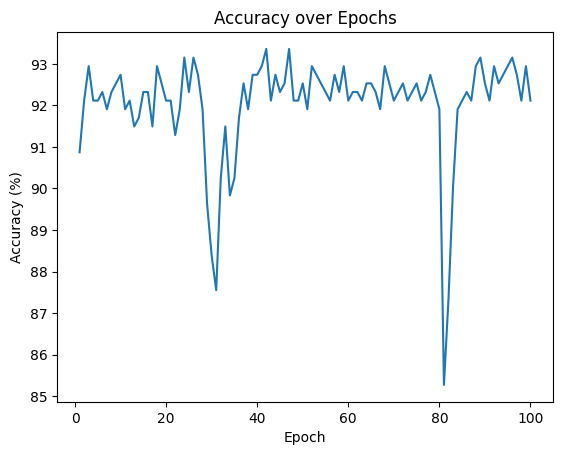

In [70]:
# 訓練過程中記錄準確性
epochs = 100
accuracy_list = []

for epoch in range(epochs):
    net.train()
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # 訓練結束後計算測試準確性
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    accuracy_list.append(accuracy)

print('Finished Training')

# 繪製準確性變化曲線
plt.plot(range(1, epochs + 1), accuracy_list)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy over Epochs')
plt.show()

### **<font color=skyblue>結果的觀察與討論：</font>**
因好奇迭代訓練次數的影響，故記錄1~100次迭代訓練次數的結果並繪製圖型，可以發現並非迭代訓練次數越多結果就會越準確

### **<font color=skyblue>總結：</font>**
前面已說明測試集部分準確率已達92 \%，是個不錯的表現，但因好奇迭代訓練次數（epochs）的影響，在上圖額外透過調整迭代訓練次數的方式，記錄1~100次訓練後，測試集部分的準確性變化曲線，可以發現在1~100次迭代訓練次數中準確率大部分均達90%以上的，而迭代訓練次數並非越多越好，如上圖可以發現迭代訓練次數在30次與80次左右有一次明顯的低點，因此可以下一個結論，如果遇到測試集部分的準確率不好的情況，如不想改變模型的結構與其他的超參數，可以多讓資料運行一次，有可能會有不錯的表現